In [ ]:
# Importing required Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading The Raw Data

In [2]:
 
# ============================================================
# STEP 1.2 — Load the raw data
# ============================================================
# The dataset has NO header row. We must assign column names manually.
# Columns: engine_id, cycle, 3 operational settings, 21 sensors
 
column_names = [
    'engine_id', 'cycle',
    'setting_1', 'setting_2', 'setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
    'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
    'sensor_21'
]
 
# Load the training data (no header)
train_df = pd.read_csv(
    r"C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\spacecraft-ai\data\train_FD001.txt",
    sep=r'\s+',       # one or more spaces as delimiter
    header=None,       # no header row in the file
    names=column_names # assign our column names
)
 
print("-" * 60)
print("STEP 1.2: Dataset loaded successfully!")
print("-" * 60)
print(f"Shape: {train_df.shape}")          # (rows, columns)
print(f"Engines: {train_df['engine_id'].nunique()}")  # how many engines
print(f"Columns: {train_df.columns.tolist()}")
print()
print("First 5 rows:")
print(train_df.head())
print()
print("Basic statistics:")
print(train_df.describe().round(2))

------------------------------------------------------------
STEP 1.2: Dataset loaded successfully!
------------------------------------------------------------
Shape: (20631, 26)
Engines: 100
Columns: ['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']

First 5 rows:
   engine_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0          1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1          1      2     0.0019    -0.0003      100.0    518.67    642.15   
2          1      3    -0.0043     0.0003      100.0    518.67    642.35   
3          1      4     0.0007     0.0000      100.0    518.67    642.35   
4          1      5    -0.0019    -0.0002      100.0    518.67    642.37   



# What the Columns are:

engine_id  : Which engine (1 to 100 in FD001)

cycle      : Time step (1, 2, 3... until engine fails)

setting_1-3: Operational conditions (altitude, Mach, throttle)

sensor_1   : Total temperature at fan inlet (°R)

sensor_2   : Total temperature at LPC outlet (°R)

sensor_3   : Total temperature at HPC outlet (°R)

sensor_4   : Total temperature at LPT outlet (°R)

sensor_5   : Pressure at fan inlet (psia)

sensor_6   : Total pressure in bypass-duct (psia)

sensor_7   : Total pressure at HPC outlet (psia)

sensor_8   : Physical fan speed (rpm)

sensor_9   : Physical core speed (rpm)

sensor_10  : Engine pressure ratio

sensor_11  : Static pressure at HPC outlet (psia)

sensor_12  : Ratio of fuel flow to Ps30 (pps/psi)

sensor_13  : Corrected fan speed (rpm)

sensor_14  : Corrected core speed (rpm)

sensor_15  : Bypass ratio

sensor_16  : Burner fuel-air ratio

sensor_17  : Bleed enthalpy

sensor_18  : Demanded fan speed (rpm)

sensor_19  : Demanded corrected fan speed (rpm)

sensor_20  : HPT coolant bleed (lbm/s)

sensor_21  : LPT coolant bleed (lbm/s)


In [3]:
# Checking which sensors have near-zero variance (carrying no useful info)
print("\n" + "-" * 60)
print("STEP 1.3: Sensor variance check")
print("-" * 60)
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
variances = train_df[sensor_cols].var().round(4)
print("\nSensor variances:")
print(variances)
low_variance = variances[variances < 0.01].index.tolist()
print(f"\nLow-variance (near-constant) sensors to DROP: {low_variance}")


------------------------------------------------------------
STEP 1.3: Sensor variance check
------------------------------------------------------------

Sensor variances:
sensor_1       0.0000
sensor_2       0.2501
sensor_3      37.5910
sensor_4      81.0109
sensor_5       0.0000
sensor_6       0.0000
sensor_7       0.7834
sensor_8       0.0050
sensor_9     487.6536
sensor_10      0.0000
sensor_11      0.0713
sensor_12      0.5440
sensor_13      0.0052
sensor_14    363.9005
sensor_15      0.0014
sensor_16      0.0000
sensor_17      2.3987
sensor_18      0.0000
sensor_19      0.0000
sensor_20      0.0327
sensor_21      0.0117
dtype: float64

Low-variance (near-constant) sensors to DROP: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_8', 'sensor_10', 'sensor_13', 'sensor_15', 'sensor_16', 'sensor_18', 'sensor_19']


# Exploratory Data Analysis

Generating EDA plots

## Sensor trends for a single engine
This shows how sensor readings change as the engine degrades

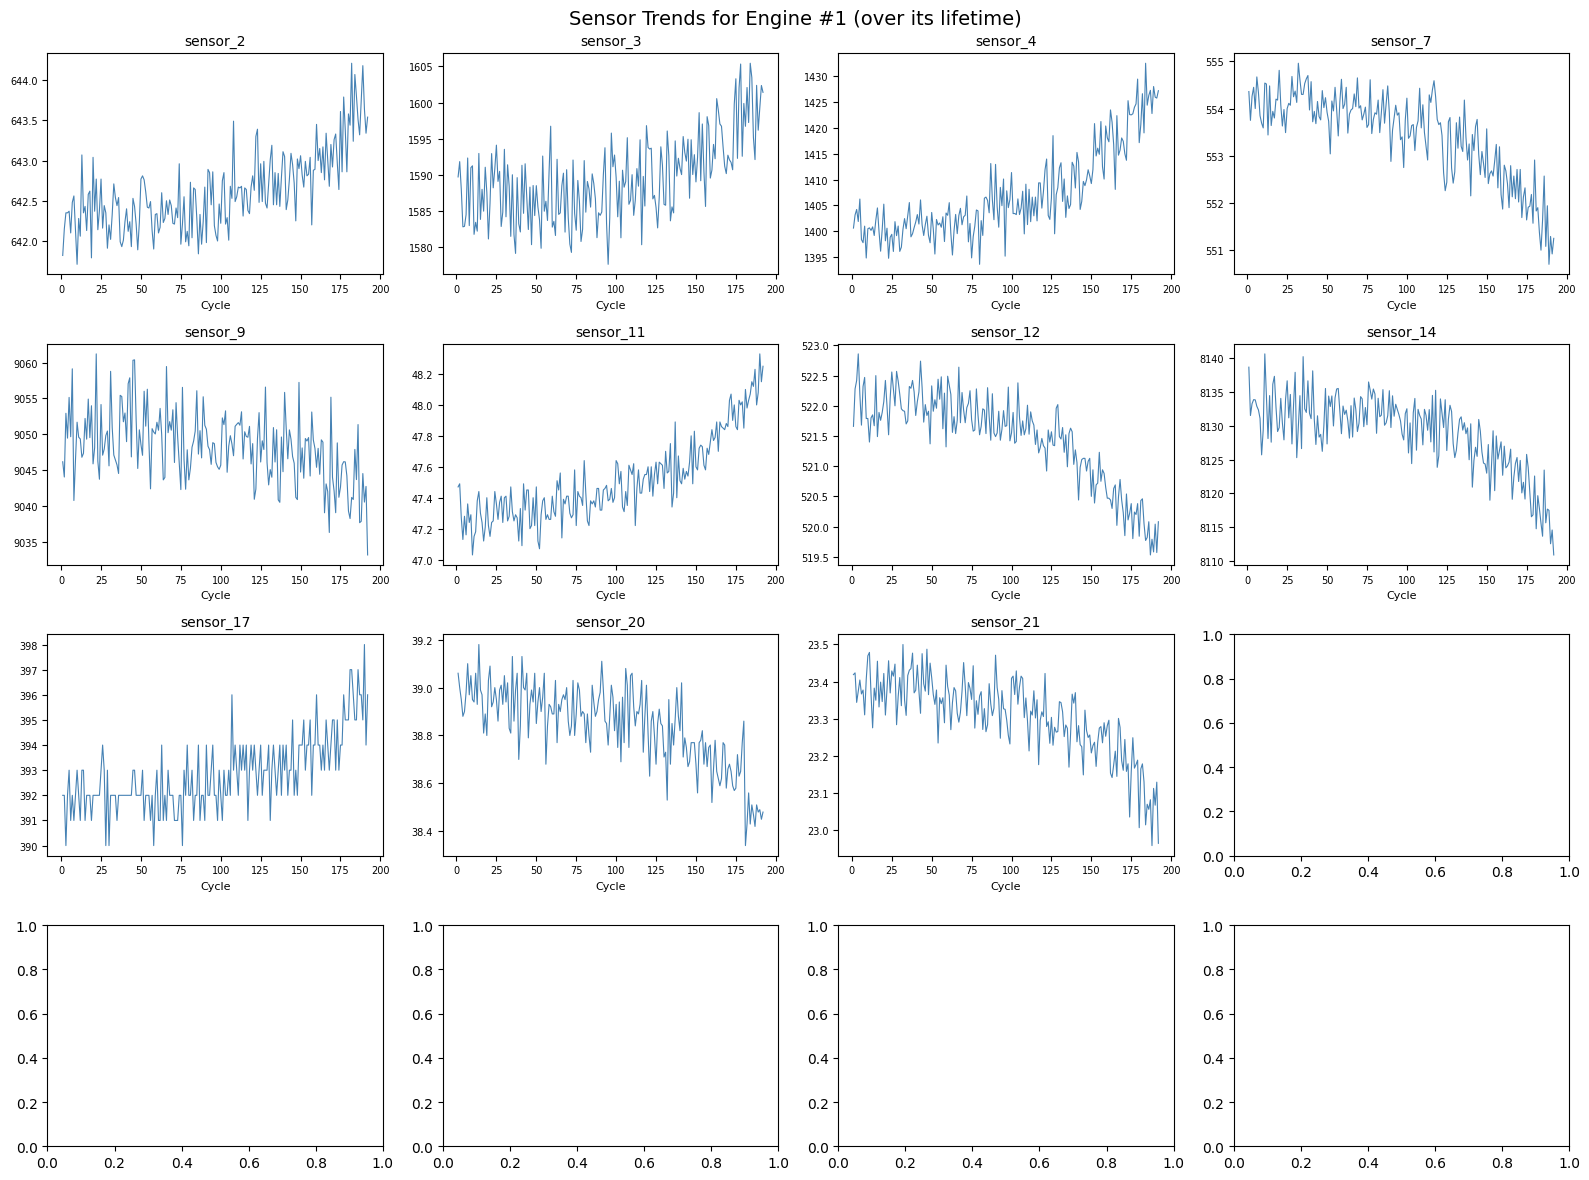

Saved: results/sensor_trends_engine1.png


In [6]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle('Sensor Trends for Engine #1 (over its lifetime)', fontsize=14)
 
engine_1 = train_df[train_df['engine_id'] == 1]
 
# Pick 16 sensors that have meaningful variance
useful_sensors = [s for s in sensor_cols if s not in low_variance][:16]
 
for idx, sensor in enumerate(useful_sensors):
    ax = axes[idx // 4, idx % 4]
    ax.plot(engine_1['cycle'], engine_1[sensor], linewidth=0.8, color='steelblue')
    ax.set_title(sensor, fontsize=10)
    ax.set_xlabel('Cycle', fontsize=8)
    ax.tick_params(labelsize=7)
 
plt.tight_layout()
plt.savefig(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\spacecraft-ai\results\sensor_trends_engine1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/sensor_trends_engine1.png")

## How long does each engine last?

In [ ]:
engine_lifetimes = train_df.groupby('engine_id')['cycle'].max()
 
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(engine_lifetimes.index, engine_lifetimes.values, color='steelblue', alpha=0.7)
ax.set_xlabel('Engine ID')
ax.set_ylabel('Lifetime (cycles)')
ax.set_title('Engine Lifetimes — How long each engine ran before failure')
ax.axhline(y=engine_lifetimes.mean(), color='red', linestyle='--',
           label=f'Mean = {engine_lifetimes.mean():.0f} cycles')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\spacecraft-ai\results\sensor_trends_engine1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/engine_lifetimes.png")